# ДЗ 13. Когда-нибудь это закончится?
## Симуляция распространения болезни на сети аэропортов (NetworkX)

### Цель
Смоделировать распространение инфекции по авиарейсам США (SI-модель) и понять,
как структура сети предсказывает скорость заражения городов.

### Данные
- `flight.txt` — рейсы: `Source`, `Destination`, `StartTime`, `EndTime`, `Duration`
- `airport_data.csv` — справочник аэропортов (id, город, название)
- Старт инфекции: **Allentown** (`node_id = 0`)

### Структура работы
1. **Часть 1** — функция одной SI-симуляции
2. **Часть 2** — влияние вероятности заражения `p`
3. **Часть 3** — метрики NetworkX и корреляция со временем заражения


---
## Блок 0. Импорты и настройки

Подключаем библиотеки:
- `pandas` / `numpy` — таблицы и численные расчёты
- `networkx` — граф аэропортов
- `matplotlib` / `seaborn` — графики
- `scipy.stats.spearmanr` — корреляция Спирмена


In [1]:
# --- Блок 0: импорты ---
import random
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, display
from scipy.stats import spearmanr

# Внешний вид графиков
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)

# Фиксируем зерно случайности — результаты воспроизводимы
RANDOM_SEED = 42
START_NODE = 0  # Allentown (стартовый заражённый аэропорт)
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("Импорты загружены. Старт инфекции: Allentown (id=0)")


Импорты загружены. Старт инфекции: Allentown (id=0)


---
## Блок 1. Загрузка и подготовка данных

Читаем CSV с аэропортами и рейсами.
**Важно:** рейсы сортируем по `StartTime` — симуляция идёт в хронологическом порядке
(как будто «проигрываем» месяц полётов слева направо).


In [2]:
# --- Блок 1: загрузка данных ---
airport_data = pd.read_csv("airport_data.csv")
flight_data = pd.read_csv("flight.txt", sep=" ")

# Сортируем рейсы по времени вылета (и прибытия при равенстве)
flight_data = flight_data.sort_values(
    ["StartTime", "EndTime"], kind="mergesort"
).reset_index(drop=True)

# Словарь id аэропорта -> человекочитаемое название
id_to_name = airport_data.set_index("id")["airport name"].to_dict()
n_airports = airport_data.shape[0]  # всего узлов в сети

print(f"Аэропортов: {n_airports}")
print(f"Рейсов: {len(flight_data)}")
print(
    f"Старт: id={START_NODE}, "
    f"{airport_data.loc[airport_data.id == START_NODE, 'city'].iloc[0]} — "
    f"{id_to_name[START_NODE]}"
)
flight_data.head(3)


Аэропортов: 279
Рейсов: 180192
Старт: id=0, Allentown — Lehigh Valley Intl


,Source,Destination,StartTime,EndTime,Duration
0,27,49,1229231100,1229246760,15660
1,30,2,1229233200,1229245980,12780
2,251,20,1229235000,1229246340,11340


---
## Блок 2. Часть 1 — функция SI-симуляции

### Модель SI
- **S** (susceptible) — здоровый аэропорт  
- **I** (infected) — заражённый аэропорт  

Правило: если самолёт вылетает из уже заражённого города в ещё здоровый,
то с вероятностью `p` destination заражается в момент **прибытия** (`EndTime`).

### Что возвращает функция
Словарь `{время_заражения: название_аэропорта}` — как требует условие ДЗ.

Дополнительно сохраняем `last_infection_times`: `{id_аэропорта: время}` —
удобнее для аналитики в частях 2–3.


In [3]:
# --- Блок 2: симуляция одного прохода по датасету ---
def simulate_infection(flights_df, start_node=0, p=0.01, airport_names=None, seed=None):
    """Один проход SI-симуляции по всем рейсам.

    Параметры
    ---------
    flights_df : DataFrame
        Рейсы (уже отсортированы по времени).
    start_node : int
        Id аэропорта, где инфекция началась.
    p : float
        Вероятность заражения при «заразном» рейсе.
    airport_names : dict
        id -> название аэропорта.
    seed : int, optional
        Seed для random (воспроизводимость).

    Возвращает
    ----------
    dict
        время_заражения -> название_аэропорта
    """
    if airport_names is None:
        airport_names = id_to_name
    if seed is not None:
        random.seed(seed)

    # Множество уже заражённых id
    infected = {start_node}

    # Время заражения старта: первый вылет из этого аэропорта
    start_flights = flights_df.loc[flights_df["Source"] == start_node, "StartTime"]
    start_time = (
        int(start_flights.min())
        if len(start_flights)
        else int(flights_df["StartTime"].min())
    )

    infection_log = {start_time: airport_names[start_node]}
    infection_times = {start_node: start_time}

    # Проход по всем рейсам (itertuples — быстрее iterrows)
    for row in flights_df.itertuples(index=False):
        src, dst = row.Source, row.Destination
        # «Заразный» рейс: источник заражён, назначение ещё нет
        if src in infected and dst not in infected and random.random() < p:
            infected.add(dst)
            t = int(row.EndTime)  # заражение в момент посадки
            infection_times[dst] = t
            infection_log[t] = airport_names[dst]

    # Кладём id->время в атрибут функции (для частей 2–3)
    simulate_infection.last_infection_times = infection_times
    return infection_log


def infection_times_by_airport(flights_df, start_node=0, p=0.01, seed=None):
    """Обёртка: возвращает dict id_аэропорта -> время заражения."""
    simulate_infection(flights_df, start_node=start_node, p=p, seed=seed)
    return dict(simulate_infection.last_infection_times)


# Демонстрация одной симуляции
demo = simulate_infection(flight_data, start_node=START_NODE, p=0.5, seed=0)
print(f"Заражено аэропортов (p=0.5, seed=0): {len(demo)}")
print("Первые 8 заражений (по времени):")
for t, name in sorted(demo.items())[:8]:
    print(f"  {t}: {name}")


Заражено аэропортов (p=0.5, seed=0): 195
Первые 8 заражений (по времени):
  1229245200: Lehigh Valley Intl
  1229260500: Robert Gray Aaf
  1229261520: Norfolk Intl
  1229261880: Hartsfield Jackson Atlanta Intl
  1229262000: Monterey Peninsula
  1229262060: Charlotte Douglas Intl
  1229262300: Rochester
  1229262600: San Antonio Intl


---
## Блок 3. Часть 2 — влияние вероятности `p`

Для каждой `p ∈ {0.01, 0.05, 0.1, 0.5, 1.0}` запускаем **10** симуляций.

Каждые **12 часов** считаем, какой **средний процент** аэропортов уже заражён.

Если график `part2_infection_vs_p.png` уже сохранён (после `hw13_disease_spread.py`),
ячейка просто покажет его — без повторного долгого прогона.


График уже есть — показываем part2_infection_vs_p.png


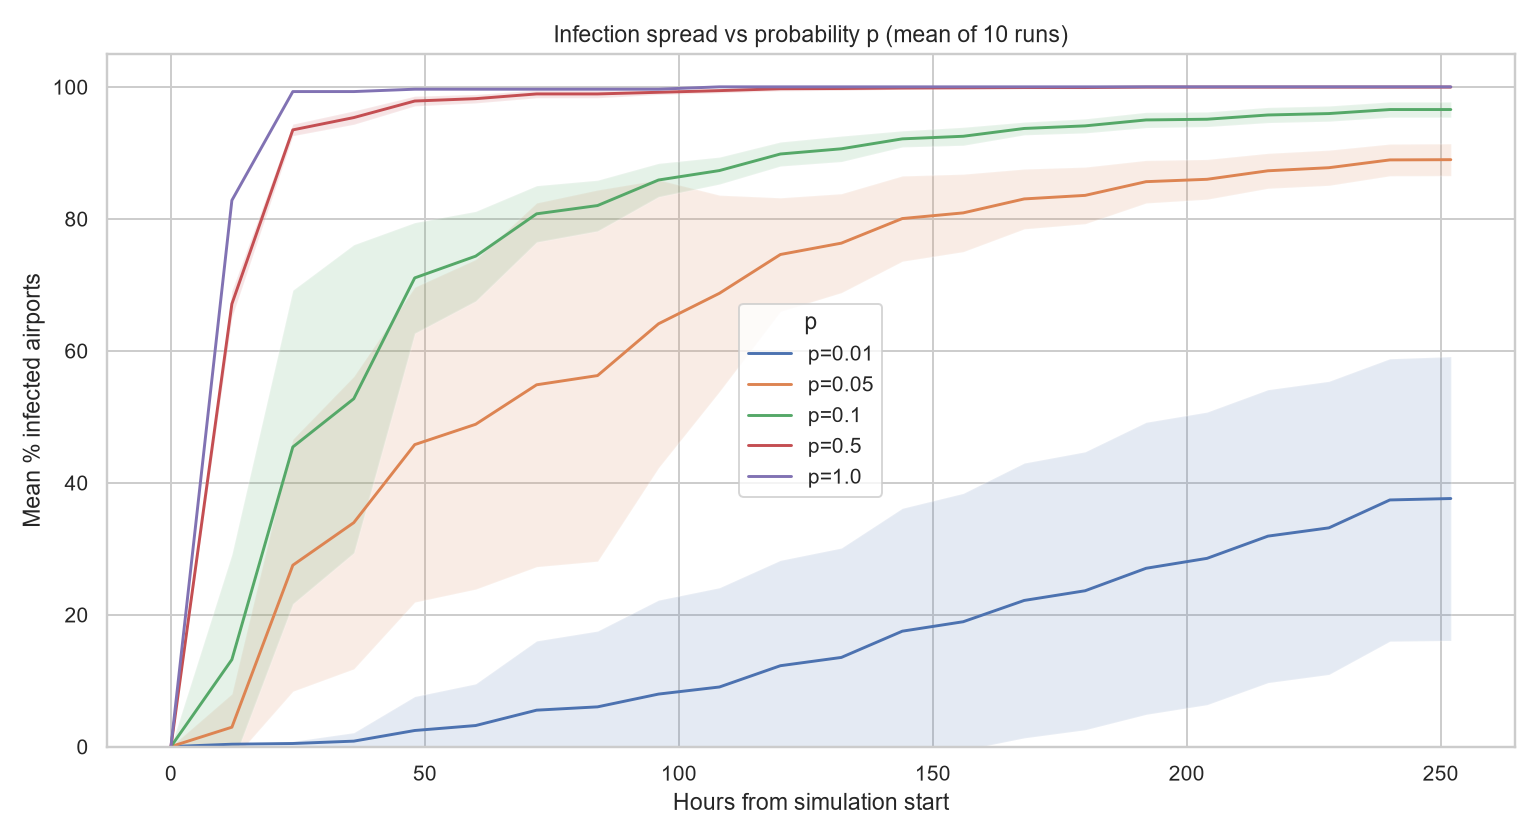

Ориентиры по финальному покрытию (из полного прогона):
  p=0.01 → ~38%,  p=0.05 → ~89%,  p=0.1 → ~97%,  p≥0.5 → ~100%


In [4]:
# --- Блок 3: сетка по p и кривые заражения ---
P_VALUES = [0.01, 0.05, 0.1, 0.5, 1.0]
N_RUNS_P = 10
TWELVE_HOURS = 12 * 3600  # 12 часов в секундах (unix time)

t_min = int(flight_data["StartTime"].min())
t_max = int(flight_data["EndTime"].max())
# Моменты времени, в которые считаем долю заражённых
time_grid = np.arange(t_min, t_max + TWELVE_HOURS, TWELVE_HOURS)


def infected_percent_curve(infection_times, time_grid, n_airports):
    """Для каждого момента time_grid — % уже заражённых аэропортов."""
    times = np.array(sorted(infection_times.values()), dtype=np.int64)
    # searchsorted: сколько заражений произошло не позже t
    counts = np.searchsorted(times, time_grid, side="right")
    return 100.0 * counts / n_airports


RUN_PART2 = not Path("part2_infection_vs_p.png").exists()

if RUN_PART2:
    results_by_p = {}
    for p in P_VALUES:
        curves, finals = [], []
        for run in range(N_RUNS_P):
            times = infection_times_by_airport(
                flight_data, start_node=START_NODE, p=p, seed=RANDOM_SEED + run
            )
            curves.append(infected_percent_curve(times, time_grid, n_airports))
            finals.append(len(times))
        results_by_p[p] = {
            "mean_curve": np.mean(curves, axis=0),
            "std_curve": np.std(curves, axis=0),
            "mean_final": float(np.mean(finals)),
        }
        print(
            f"p={p:>4}: средний финал {results_by_p[p]['mean_final']:.1f}/{n_airports} "
            f"({100 * results_by_p[p]['mean_final'] / n_airports:.1f}%)"
        )

    hours_from_start = (time_grid - t_min) / 3600.0
    fig, ax = plt.subplots(figsize=(11, 6))
    for p in P_VALUES:
        mean_c = results_by_p[p]["mean_curve"]
        std_c = results_by_p[p]["std_curve"]
        ax.plot(hours_from_start, mean_c, label=f"p={p}")
        # Полоса = среднее ± std по 10 запускам
        ax.fill_between(hours_from_start, mean_c - std_c, mean_c + std_c, alpha=0.15)
    ax.set_xlabel("Часы от начала симуляции")
    ax.set_ylabel("Средний % заражённых аэропортов")
    ax.set_title("Влияние вероятности p на скорость распространения (10 запусков)")
    ax.legend(title="p")
    ax.set_ylim(0, 105)
    plt.tight_layout()
    plt.savefig("part2_infection_vs_p.png", dpi=140)
    plt.show()
else:
    print("График уже есть — показываем part2_infection_vs_p.png")
    display(Image("part2_infection_vs_p.png"))
    print("Ориентиры по финальному покрытию (из полного прогона):")
    print("  p=0.01 → ~38%,  p=0.05 → ~89%,  p=0.1 → ~97%,  p≥0.5 → ~100%")


### Выводы по части 2
- При малом `p` инфекция часто не успевает «зажечь» хабы — покрытие сети низкое.
- Уже при `p ≈ 0.1` почти вся сеть заражена: достаточно нескольких успешных рейсов до крупных узлов.
- `p = 1` — верхняя граница: каждый рейс из заражённого города гарантированно заражает destination.


---
## Блок 4. Часть 3 — граф NetworkX

Строим **ненаправленный** граф:
- вершины — аэропорты;
- ребро между A и B есть, если был хотя бы один рейс A→B или B→A;
- **вес** = (число рейсов между A и B в обе стороны) / (всего рейсов в датасете).

Пример из условия: 5 + 10 рейсов при 150 всего → вес `0.1`.


In [5]:
# --- Блок 4: построение взвешенного графа ---
total_flights = len(flight_data)
pair_counts = defaultdict(int)

# Считаем число рейсов для каждой неупорядоченной пары аэропортов
for row in flight_data.itertuples(index=False):
    a, b = int(row.Source), int(row.Destination)
    if a == b:
        continue  # петли не нужны
    pair_counts[(min(a, b), max(a, b))] += 1

G = nx.Graph()
G.add_nodes_from(airport_data["id"].tolist())
for (a, b), cnt in pair_counts.items():
    G.add_edge(a, b, weight=cnt / total_flights, n_flights=cnt)

print(f"Вершин: {G.number_of_nodes()}, рёбер: {G.number_of_edges()}")
print(f"Компонент связности: {nx.number_connected_components(G)}")
print(f"Пример веса Allentown–CLE: {G.edges[0, 1]['weight']:.6f}")


Вершин: 279, рёбер: 2088
Компонент связности: 1
Пример веса Allentown–CLE: 0.000294


---
## Блок 5. Медианное время заражения (50 симуляций, p=0.5)

Запускаем симуляцию 50 раз из Allentown с `p=0.5`.
Для каждого города берём **медиану** времени заражения (в часах от начала месяца).

Если файл `part3_metrics.csv` уже есть — загружаем его.


In [6]:
# --- Блок 5: медианное время заражения ---
N_RUNS_MEDIAN = 50
P_MEDIAN = 0.5
metrics_path = Path("part3_metrics.csv")
RUN_PART3 = not metrics_path.exists()

if RUN_PART3:
    infection_runs = defaultdict(list)  # id -> список времён заражения по запускам
    for run in range(N_RUNS_MEDIAN):
        times = infection_times_by_airport(
            flight_data,
            start_node=START_NODE,
            p=P_MEDIAN,
            seed=RANDOM_SEED + 1000 + run,
        )
        for node, t in times.items():
            infection_runs[node].append(t)

    # Медиана в часах относительно начала симуляции
    median_hours = {
        node: (float(np.median(ts)) - t_min) / 3600.0
        for node, ts in infection_runs.items()
    }

    # Метрики графа для каждой вершины
    clustering = nx.clustering(G)           # локальная плотность связей соседей
    degree = dict(G.degree())               # число соседей
    betweenness = nx.betweenness_centrality(G)  # доля кратчайших путей через вершину

    metrics_df = airport_data[["id", "city", "airport name", "symbol"]].copy()
    metrics_df["median_infection_hours"] = metrics_df["id"].map(median_hours)
    metrics_df["clustering"] = metrics_df["id"].map(clustering)
    metrics_df["degree"] = metrics_df["id"].map(degree)
    metrics_df["betweenness"] = metrics_df["id"].map(betweenness)
    metrics_df.to_csv(metrics_path, index=False)
else:
    print("Загружаем сохранённые метрики из part3_metrics.csv")
    metrics_df = pd.read_csv(metrics_path)

plot_df = metrics_df.dropna(subset=["median_infection_hours"]).copy()
print(f"Городов с медианным временем: {len(plot_df)} / {n_airports}")
plot_df.head()


Загружаем сохранённые метрики из part3_metrics.csv
Городов с медианным временем: 279 / 279


,id,city,airport name,symbol,median_infection_hours,clustering,degree,betweenness
0,0,Allentown,Lehigh Valley Intl,ABE,3.916667,1.000000,5,0.000000
1,1,Cleveland,Cleveland Hopkins Intl,CLE,8.750000,0.528736,58,0.004675
2,2,Charlotte,Charlotte Douglas Intl,CLT,7.266667,0.421911,66,0.014125
3,3,Chicago,Chicago Ohare Intl,ORD,7.500000,0.170084,133,0.118203
4,4,Atlanta,Hartsfield Jackson Atlanta Intl,ATL,6.350000,0.128950,156,0.219629


---
## Блок 6. Scatter-plot’ы и корреляция Спирмена

Сравниваем медианное время заражения с тремя метриками:
1. **clustering** — коэффициент кластеризации  
2. **degree** — степень вершины  
3. **betweenness** — посредничество (betweenness centrality)

Спирмен показывает **монотонную** связь (не обязательно линейную).
Ожидаем **отрицательную** корреляцию у degree/betweenness: хабы заражаются раньше.


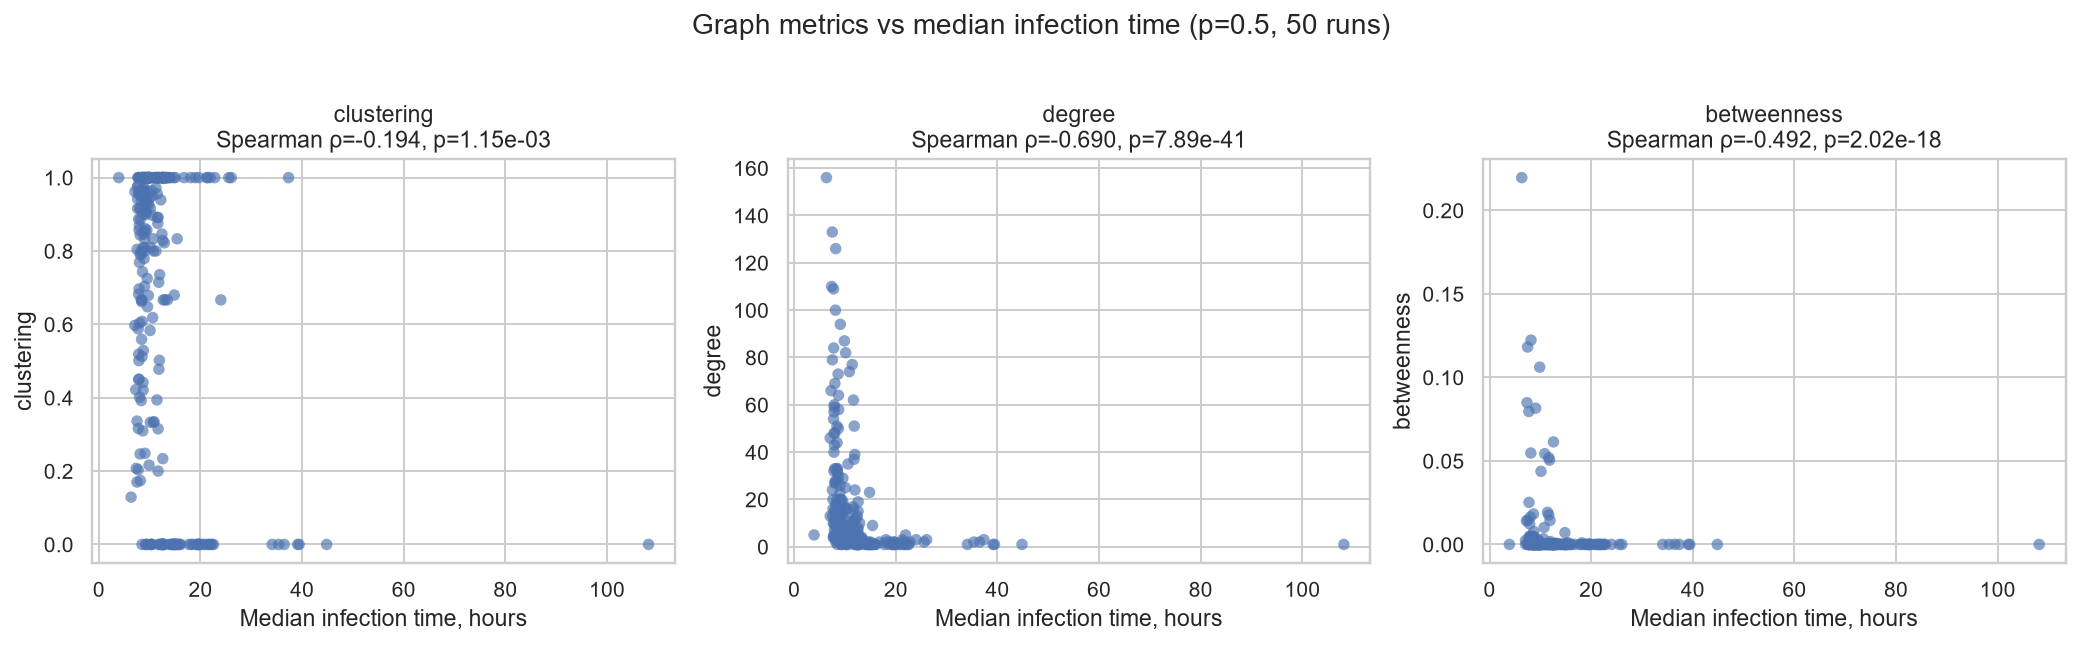

Корреляции Спирмена (время заражения ↔ метрика):
  clustering    : rho=-0.1936, p-value=1.151e-03
  degree        : rho=-0.6904, p-value=7.888e-41
  betweenness   : rho=-0.4921, p-value=2.021e-18

Сильнее всего скоррелирована: degree (|rho|=0.6904)


In [7]:
# --- Блок 6: визуализация и Spearman ---
metric_cols = ["clustering", "degree", "betweenness"]

if Path("part3_scatter_metrics.png").exists() and not RUN_PART3:
    display(Image("part3_scatter_metrics.png"))
else:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    for ax, col in zip(axes, metric_cols):
        x = plot_df["median_infection_hours"]
        y = plot_df[col]
        ax.scatter(x, y, alpha=0.65, edgecolor="none", s=35)
        coef, pval = spearmanr(x, y)
        ax.set_xlabel("Медианное время заражения, часы")
        ax.set_ylabel(col)
        ax.set_title(f"{col}\nSpearman rho={coef:.3f}, p={pval:.2e}")
    plt.suptitle(
        "Метрики графа vs медианное время заражения (p=0.5, 50 симуляций)", y=1.02
    )
    plt.tight_layout()
    plt.savefig("part3_scatter_metrics.png", dpi=140, bbox_inches="tight")
    plt.show()

print("Корреляции Спирмена (время заражения ↔ метрика):")
spearman_results = {}
for col in metric_cols:
    coef, pval = spearmanr(plot_df["median_infection_hours"], plot_df[col])
    spearman_results[col] = (coef, pval)
    print(f"  {col:14s}: rho={coef:+.4f}, p-value={pval:.3e}")

ranked = sorted(spearman_results.items(), key=lambda kv: abs(kv[1][0]), reverse=True)
print(
    f"\nСильнее всего скоррелирована: {ranked[0][0]} "
    f"(|rho|={abs(ranked[0][1][0]):.4f})"
)


### Интерпретация (часть 3)

| Метрика | Типичный ρ | Смысл |
|---------|------------|--------|
| **degree** | ≈ −0.69 | больше соседей → раньше заражение |
| **betweenness** | ≈ −0.49 | «мосты» сети тоже заражаются рано |
| **clustering** | ≈ −0.19 | слабая связь |

**Degree** — лучший предиктор порядка заражения: хабы получают много рейсов
из уже заражённых городов и сами быстро становятся источниками инфекции.
Betweenness ловит транзитные узлы, но слабее отражает локальный поток.
Clustering почти не помогает: плотные периферийные клики заражаются поздно.

**Итог:** структура авиасети (особенно степень вершины) действительно помогает
предсказать, кто заболеет раньше — это и есть эффект заражения хабов.
